In [9]:
# Step 1 : Create Dataset
# Task 1.1 : Input Generation
import numpy as np
X = np.linspace(0, 10, 50).reshape(-1,1)
print("Shape of X:", X.shape)

Shape of X: (50, 1)


**Explanation**

**What this step does:**
Creates 50 input samples between 0 and 10.

**Why it is needed:**
This range allows observation of nonlinear behavior that linear models cannot fit.

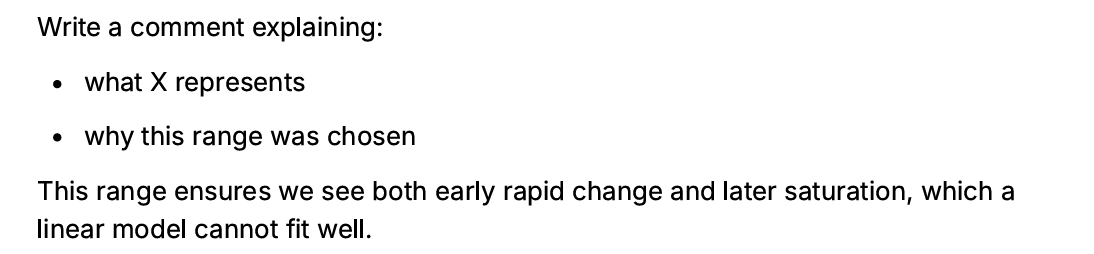

In [ ]:
# X represents the input feature values.
# The range 0–10 allows us to see early rapid growth and later slow growth,
# which cannot be fitted well by a straight line.

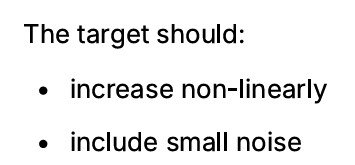

In [10]:
# Task 1.2 : Target Generation
noise = np.random.normal(0, 0.2 , size=(50,1))
y = np.log(X + 1) + noise
print("Shape of y:" , y.shape)

Shape of y: (50, 1)


**Explanation**

**What this step does:**
Creates nonlinear target values using log function and noise.

**Why it is needed:**
To demonstrate why nonlinear models are necessary.

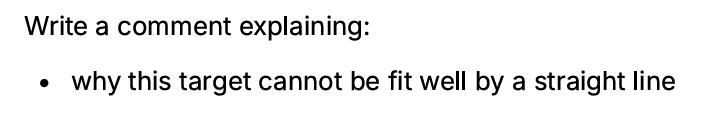

In [ ]:
# This logarithmic function grows quickly at first and slows later.
# A straight line has only one slope, so it cannot fit this shape well.

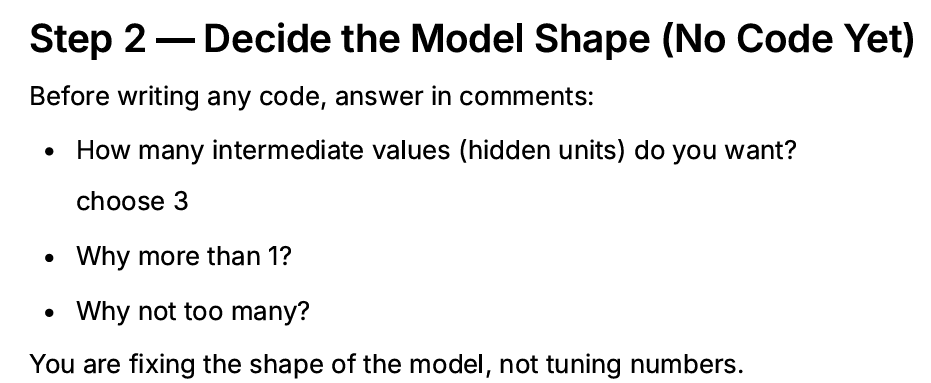

In [ ]:
# Why more than 1:
# Multiple hidden units allow the model to represent more complex patterns.

# Why not too many:
# Too many units increase instability and overfitting.

**Explanation**

**What this step does:**
Defines number of hidden neurons.

**Why it is needed:**
Hidden units allow the model to bend and learn nonlinear relationships.

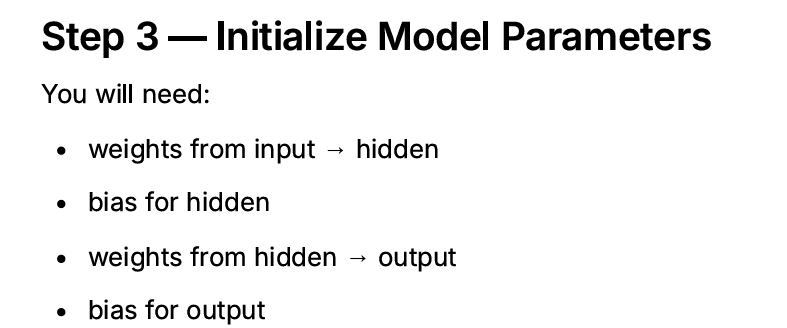

In [11]:
W1 = np.random.uniform(-1,1, size=(1,3))
b1 = np.zeros((1,3))

W2 = np.random.uniform(-1,1, size=(3,1))
b2 = np.zeros((1,1))

print("W1 shape", W1.shape)
print("W2 shape", W2.shape)

W1 shape (1, 3)
W2 shape (3, 1)


**Explanation**

**What this step does:**
Creates initial parameters randomly.

**Why it is needed:**
Learning adjusts these parameters to reduce error.

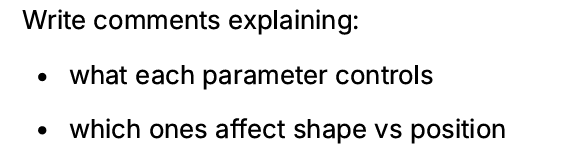

In [ ]:
# W1 controls how input affects hidden layer.
# b1 shifts hidden layer output.

# W2 controls how hidden layer affects output.
# b2 shifts final prediction.

# Weights affect shape of curve.
# Bias affects vertical position.

In [12]:
# Step 4 : Activation Function (ReLu)
# Task 4.1 : Activation
def activation(z):
  return np.maximum(0,z)

In [13]:
# Task 4.2 : Activation Slope
def activation_slope(z):
  return (z > 0).astype(float)

**Explanation**

**What this step does:**
Defines nonlinear transformation (ReLU).

**Why it is needed:**
Allows the model to learn nonlinear relationships.

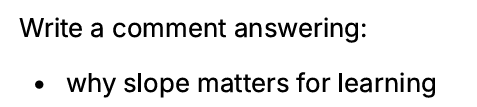

In [ ]:
# Slope tells how activation changes with input.
# Without slope, gradients cannot flow backward and learning stops.

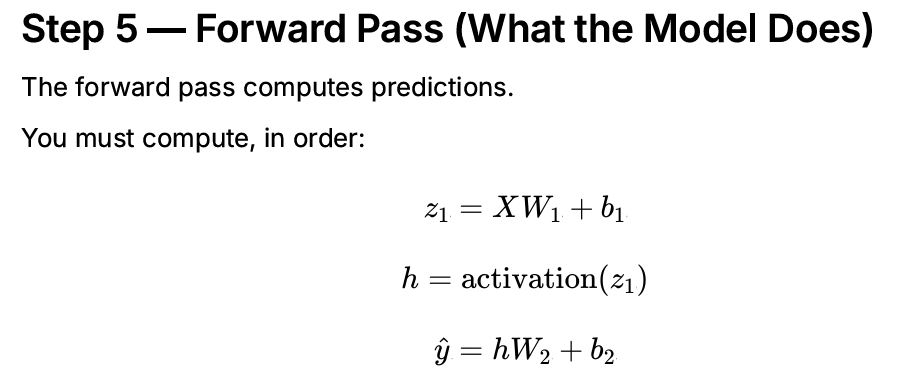

In [14]:
# Linear transformation input → hidden
z1 = X @ W1 + b1

# Activation
h = activation(z1)

# Hidden → output
y_hat = h @ W2 + b2

**Explanation**

**What this step does:**
Computes predictions step by step.

**Why it is needed:**
Predictions are required before computing loss.

In [15]:
# Step 6 : Error and Loss
# Task 6.1 : Error
error = y_hat - y

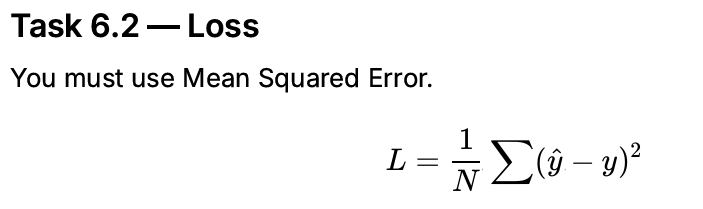

In [16]:
loss = np.mean(error ** 2)

**Explanation**

**What this step does:**
Measures prediction error.

**Why it is needed:**
Loss guides parameter updates.

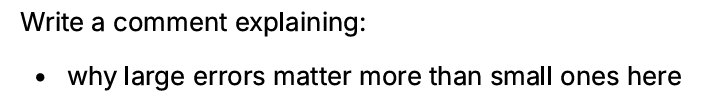

In [ ]:
# Squaring makes large errors more expensive,
# forcing stronger corrections.

In [17]:
#Step 7 — Why Slopes Matter
# Gradient means direction of maximum increase in loss.
# Moving opposite to gradient reduces loss.

**Explanation**

**What this step does:**
Defines how learning direction is determined.

**Why it is needed:**
Without gradients, parameters cannot improve.

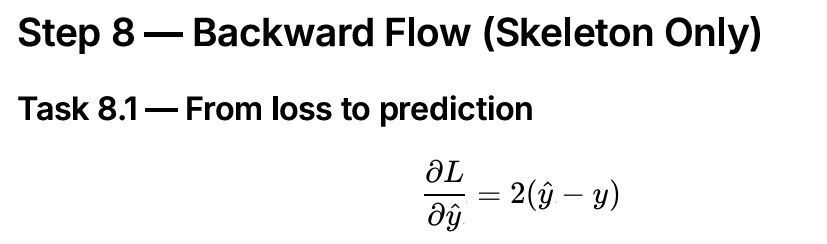

In [18]:
dL_dy = 2 * error / len(X)

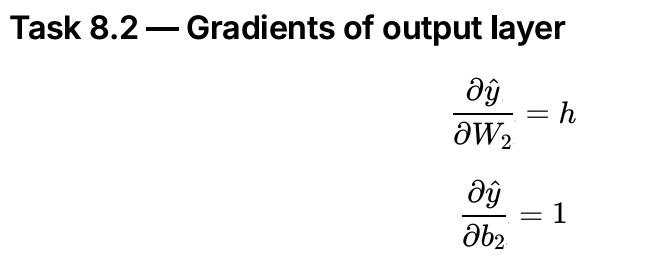

In [19]:
dL_dW2 = h.T @ dL_dy
dL_db2 = np.sum(dL_dy, axis = 0 , keepdims=True)

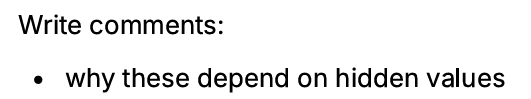

In [ ]:
# Depends on hidden layer because output comes from hidden values.

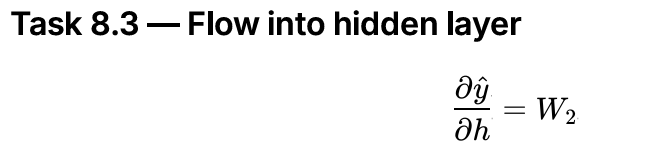

In [20]:
dL_dh = dL_dy @ W2.T

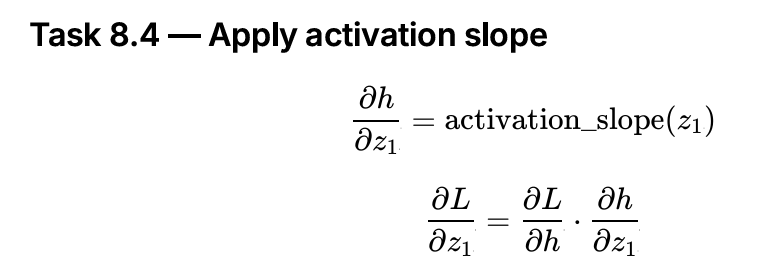

In [21]:
dL_dz1 = dL_dh * activation_slope(z1)

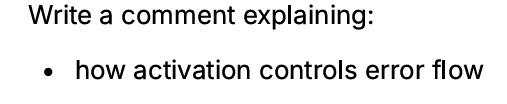

In [ ]:
# Activation controls which neurons pass error backward.

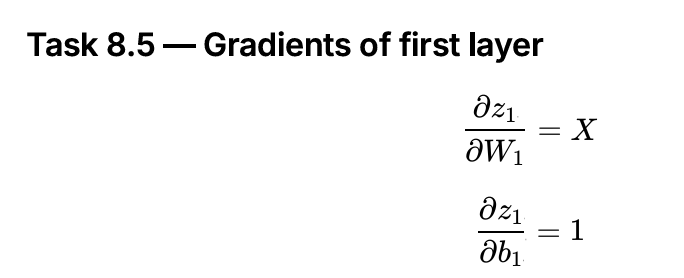

In [22]:
dL_dW1 = X.T @ dL_dz1
dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

**Explanation**

**What this step does:**
Computes gradients for all parameters.

**Why it is needed:**
Gradients tell how to update parameters.

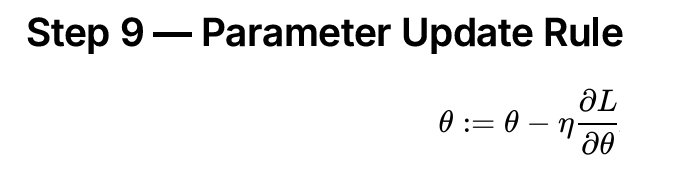

In [23]:
learning_rate = 0.01
W1 -= learning_rate * dL_dW1
b1 -= learning_rate * dL_db1

W2 -= learning_rate * dL_dW2
b2 -= learning_rate * dL_db2

**Explanation**

**What this step does:**
Adjusts parameters using gradients.

**Why it is needed:**
This is how the model learns.

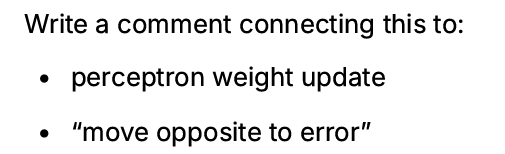

In [ ]:
# This is similar to perceptron update.
# We move parameters opposite to error direction.

In [24]:
learning_rate = 0.01
epochs = 1000
for epoch in range(epochs):
    # Forward pass
    z1 = X @ W1 + b1
    h = activation(z1)
    y_hat = h @ W2 + b2

    # Loss
    error = y_hat - y
    loss = np.mean(error ** 2)

    # Backward pass
    dL_dy = 2 * error / len(X)
    dL_dW2 = h.T @ dL_dy
    dL_db2 = np.sum(dL_dy, axis=0, keepdims=True)
    dL_dh = dL_dy @ W2.T
    dL_dz1 = dL_dh * activation_slope(z1)
    dL_dW1 = X.T @ dL_dz1
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    # Update
    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1
    W2 -= learning_rate * dL_dW2
    b2 -= learning_rate * dL_db2

    if epoch % 100 == 0:
        print("Epoch:", epoch, "Loss:", loss)

Epoch: 0 Loss: 0.197045694728229
Epoch: 100 Loss: 0.08460585416016865
Epoch: 200 Loss: 0.06506821080941726
Epoch: 300 Loss: 0.05944941000953117
Epoch: 400 Loss: 0.05782177567209106
Epoch: 500 Loss: 0.057350615219599374
Epoch: 600 Loss: 0.05721423434930098
Epoch: 700 Loss: 0.05717475104902645
Epoch: 800 Loss: 0.057163236796854505
Epoch: 900 Loss: 0.05715978590581064


**Explanation**

**What this step does:**
Repeats forward and backward passes.

**Why it is needed:**
Learning improves gradually over many iterations.

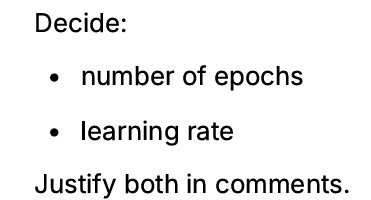

In [ ]:
# 1000 epochs allow gradual improvement.
# Learning rate is small to ensure stable learning.

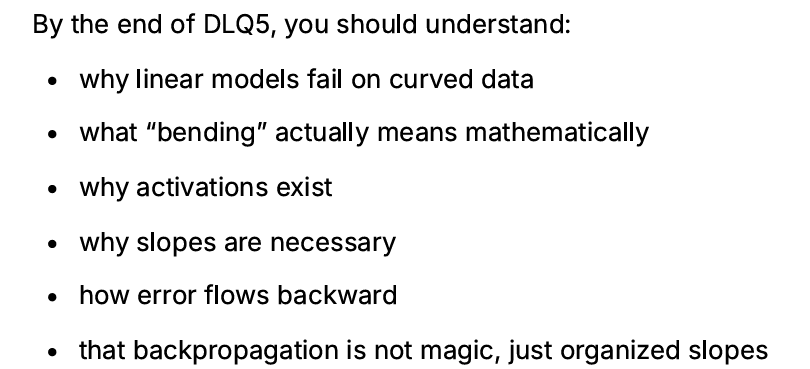

In [ ]:
# Why linear models fail:
# They can only represent straight lines.

# What bending means:
# Hidden layer + activation creates nonlinear shape.

# Why activation exists:
# It allows nonlinear transformations.

# Why slopes are necessary:
# Slopes allow gradients to flow backward.

# Backpropagation meaning:
# It is systematic gradient computation.